In [831]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [832]:
dataset = pd.read_csv("Olympics_dataset.csv")
dataset.head(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [833]:
dataset.shape

(70000, 15)

In [834]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      70000 non-null  int64  
 1   Name    70000 non-null  object 
 2   Sex     70000 non-null  object 
 3   Age     67268 non-null  float64
 4   Height  53746 non-null  float64
 5   Weight  52899 non-null  float64
 6   Team    70000 non-null  object 
 7   NOC     70000 non-null  object 
 8   Games   70000 non-null  object 
 9   Year    70000 non-null  int64  
 10  Season  70000 non-null  object 
 11  City    70000 non-null  object 
 12  Sport   70000 non-null  object 
 13  Event   70000 non-null  object 
 14  Medal   9690 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 8.0+ MB


In [835]:
dataset.columns.tolist()

['ID',
 'Name',
 'Sex',
 'Age',
 'Height',
 'Weight',
 'Team',
 'NOC',
 'Games',
 'Year',
 'Season',
 'City',
 'Sport',
 'Event',
 'Medal']

In [836]:
dataset.isnull().sum()

ID            0
Name          0
Sex           0
Age        2732
Height    16254
Weight    17101
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal     60310
dtype: int64

In [837]:
#Milestone 2

# 1. Medal — fill nulls with 'No Medal' (they didn't win, not missing data)
dataset['Medal'] = dataset['Medal'].fillna('No Medal')

In [838]:
dataset.isnull().sum()


ID            0
Name          0
Sex           0
Age        2732
Height    16254
Weight    17101
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal         0
dtype: int64

In [839]:
# Percentage of missing values
total_rows = len(dataset)

missing_cols = ['Age', 'Height', 'Weight']

print("=== MISSING VALUES PERCENTAGE ===")
for col in missing_cols:
    missing = dataset[col].isnull().sum()
    percentage = (missing / total_rows) * 100
    print(f"{col}: {missing} missing values ({percentage:.2f}%)")

=== MISSING VALUES PERCENTAGE ===
Age: 2732 missing values (3.90%)
Height: 16254 missing values (23.22%)
Weight: 17101 missing values (24.43%)


In [841]:
dataset = dataset.drop_duplicates()

In [842]:
#Milestone 2

# 1. Medal — fill nulls with 'No Medal' (they didn't win, not missing data)
dataset['Medal'] = dataset['Medal'].fillna('No Medal')

In [843]:
# 2. Age — fill with median (median is better than mean for age, less affected by outliers)
dataset['Age']=dataset['Age'].fillna(dataset['Age'].median())


In [844]:
# 3. Height — fill with median grouped by Sport (a gymnast and a basketball player have very different heights)
dataset['Height'] = dataset.groupby('Sport')['Height'].transform(
    lambda x: x.fillna(x.median())
)

In [845]:
# 4. Weight — same logic as Height, group by Sport
dataset['Weight'] = dataset.groupby('Sport')['Weight'].transform(
    lambda x: x.fillna(x.median())
)

In [846]:
dataset.isnull().sum()

ID         0
Name       0
Sex        0
Age        0
Height    90
Weight    90
Team       0
NOC        0
Games      0
Year       0
Season     0
City       0
Sport      0
Event      0
Medal      0
dtype: int64

In [848]:
# Fallback: fill any remaining nulls with the overall global median
dataset['Height'] = dataset['Height'].fillna(dataset['Height'].median())
dataset['Weight'] = dataset['Weight'].fillna(dataset['Weight'].median())

In [850]:
dataset.isnull().sum()

ID        0
Name      0
Sex       0
Age       0
Height    0
Weight    0
Team      0
NOC       0
Games     0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
dtype: int64

In [853]:
dataset.describe()

,ID,Age,Height,Weight,Year
count,69617.000000,69617.000000,69617.000000,69617.000000,69617.000000
mean,18073.006378,25.485011,175.506859,71.006672,1978.021862
std,10240.599374,6.139293,9.515330,12.969671,29.982224
min,1.000000,11.000000,127.000000,25.000000,1896.000000
25%,9303.000000,22.000000,170.000000,63.000000,1960.000000
50%,18029.000000,24.000000,176.000000,70.000000,1984.000000
75%,26965.000000,28.000000,181.000000,78.000000,2002.000000
max,35658.000000,88.000000,223.000000,214.000000,2016.000000


In [856]:
print("DATASET OVERVIEW ")
print(f"Total Athletes Records: {len(dataset)}")
print(f"Unique Athletes: {dataset['Name'].nunique()}")
print(f"Unique Countries: {dataset['NOC'].nunique()}")
print(f"Unique Sports: {dataset['Sport'].nunique()}")
print(f"Years Covered: {dataset['Year'].min()} to {dataset['Year'].max()}")
print(f"Total Events: {dataset['Event'].nunique()}")
print("")
print("AGE STATISTICS ")
print(f"Average Age: {dataset['Age'].mean():.1f} years")
print(f"Youngest Athlete: {dataset['Age'].min():.0f} years")
print(f"Oldest Athlete: {dataset['Age'].max():.0f} years")

DATASET OVERVIEW 
Total Athletes Records: 69617
Unique Athletes: 35556
Unique Countries: 226
Unique Sports: 65
Years Covered: 1896 to 2016
Total Events: 744

AGE STATISTICS 
Average Age: 25.5 years
Youngest Athlete: 11 years
Oldest Athlete: 88 years


In [858]:
## Milestone 2 — Data Processing & Transformation

#In this section we perform the following transformations:
#1. Aggregations — medals by country, average age by sport
#2. Grouping — performance metrics by gender and season
#3. Feature Engineering — BMI, Age Group, Medal Winner flag, Era
#4. Final pipeline verification

In [860]:
print("=== MEDAL DISTRIBUTION ===")
print(dataset['Medal'].value_counts())

=== MEDAL DISTRIBUTION ===
Medal
No Medal    59931
Gold         3290
Bronze       3208
Silver       3188
Name: count, dtype: int64


In [861]:
medals_only = dataset[dataset['Medal'] != 'No Medal']
top_countries = medals_only.groupby('NOC')['Medal'].count().sort_values(ascending=False).head(10)
print(" TOP 10 COUNTRIES BY MEDALS ")
print(top_countries)

 TOP 10 COUNTRIES BY MEDALS 
NOC
USA    1561
FRA     657
ITA     604
GBR     603
URS     515
GER     434
AUS     373
SWE     365
CAN     360
NED     272
Name: Medal, dtype: int64


In [862]:
# Aggregation example — total medals per country per year
medals_per_country = dataset[dataset['Medal'] != 'No Medal'].groupby(
    ['NOC', 'Year'])['Medal'].count().reset_index()
medals_per_country.columns = ['NOC', 'Year', 'Total_Medals']
print(medals_per_country.head())

   NOC  Year  Total_Medals
0  AHO  1988             1
1  ALG  1992             1
2  ALG  1996             1
3  ALG  2000             1
4  ALG  2008             1


In [863]:
# Grouping example — average age per sport
avg_age_sport = dataset.groupby('Sport')['Age'].mean().reset_index()
avg_age_sport.columns = ['Sport', 'Average_Age']
avg_age_sport = avg_age_sport.sort_values('Average_Age', ascending=False)
print(avg_age_sport.head(10))

               Sport  Average_Age
3   Art Competitions    41.554806
1           Alpinism    38.285714
30      Jeu De Paume    36.000000
38              Polo    35.081081
20     Equestrianism    33.856596
46          Shooting    33.138158
17           Curling    32.666667
48          Skeleton    32.272727
36      Motorboating    30.600000
41             Roque    30.500000


In [864]:
# Joining example — merge medal counts back into main dataset
dataset = dataset.merge(medals_per_country, on=['NOC', 'Year'], how='left')

In [865]:
# Feature 1 — BMI (Body Mass Index)
dataset['BMI'] = dataset['Weight'] / ((dataset['Height'] / 100) ** 2)
dataset['BMI'] = dataset['BMI'].round(2)



In [866]:
# Feature 2 — Age group categories
bins = [0, 18, 25, 32, 40, 100]
labels = ['Junior', 'Young Adult', 'Prime', 'Experienced', 'Veteran']
dataset['Age_Group'] = pd.cut(dataset['Age'], bins=bins, labels=labels)



In [867]:
# Feature 3 — Medal winner flag (1 = won a medal, 0 = did not)
dataset['Medal_Winner'] = dataset['Medal'].apply(
    lambda x: 1 if x != 'No Medal' else 0)


In [868]:
# Feature 4 — Olympic Era
dataset['Era'] = pd.cut(dataset['Year'],
    bins=[1890, 1939, 1959, 1979, 1999, 2020],
    labels=['Early (pre-1940)', 'Post-War', 'Cold War', 'Modern', 'Contemporary'])

print(dataset[['BMI', 'Age_Group', 'Medal_Winner', 'Era']].head(10))

     BMI    Age_Group  Medal_Winner               Era
0  24.69  Young Adult             0            Modern
1  20.76  Young Adult             0      Contemporary
2  23.24  Young Adult             0  Early (pre-1940)
3  28.68  Experienced             1  Early (pre-1940)
4  23.96  Young Adult             0            Modern
5  23.96  Young Adult             0            Modern
6  23.96  Young Adult             0            Modern
7  23.96  Young Adult             0            Modern
8  23.96        Prime             0            Modern
9  23.96        Prime             0            Modern


In [869]:
print("=== PIPELINE VERIFICATION ===")
print(f"Total Records: {len(dataset)}")
print(f"Total Columns (original + engineered): {dataset.shape[1]}")
print(f"\nNew columns added:")
print(['BMI', 'Age_Group', 'Medal_Winner', 'Era', 'Total_Medals'])
print(f"\nSample of engineered features:")
print(dataset[['Name', 'Sport', 'BMI', 'Age_Group', 'Medal_Winner', 'Era']].head())

=== PIPELINE VERIFICATION ===
Total Records: 69617
Total Columns (original + engineered): 20

New columns added:
['BMI', 'Age_Group', 'Medal_Winner', 'Era', 'Total_Medals']

Sample of engineered features:
                       Name          Sport    BMI    Age_Group  Medal_Winner  \
0                 A Dijiang     Basketball  24.69  Young Adult             0   
1                  A Lamusi           Judo  20.76  Young Adult             0   
2       Gunnar Nielsen Aaby       Football  23.24  Young Adult             0   
3      Edgar Lindenau Aabye     Tug-Of-War  28.68  Experienced             1   
4  Christine Jacoba Aaftink  Speed Skating  23.96  Young Adult             0   

                Era  
0            Modern  
1      Contemporary  
2  Early (pre-1940)  
3  Early (pre-1940)  
4            Modern  


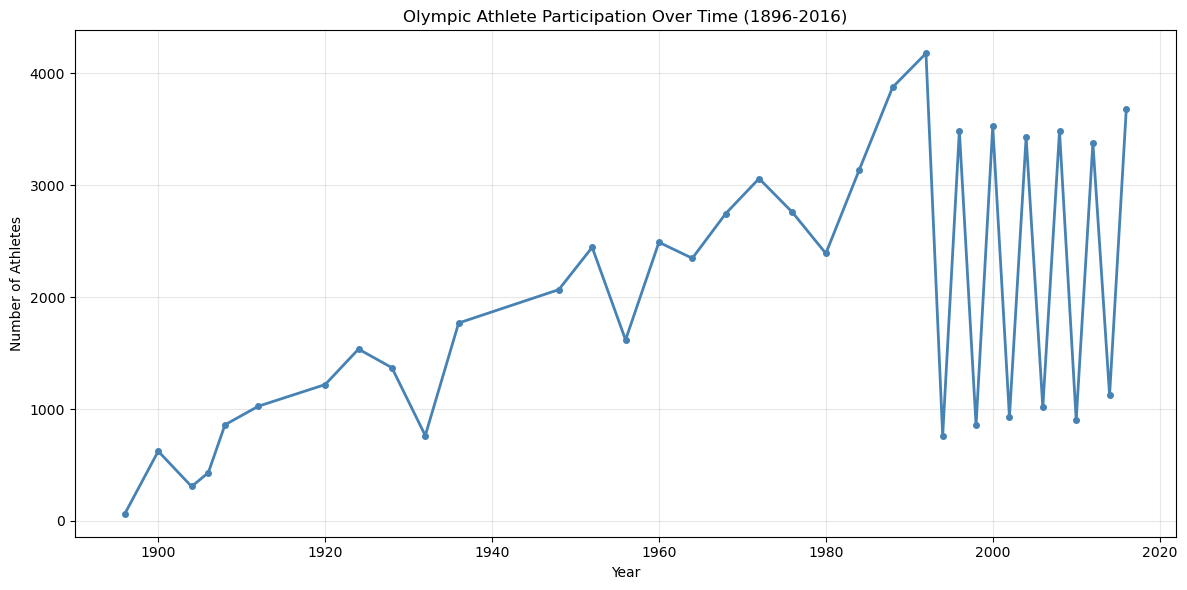

In [870]:
plt.figure(figsize=(12, 6))
yearly_participation = dataset.groupby('Year')['Name'].count()
plt.plot(yearly_participation.index, yearly_participation.values, 
         color='steelblue', linewidth=2, marker='o', markersize=4)
plt.title('Olympic Athlete Participation Over Time (1896-2016)')
plt.xlabel('Year')
plt.ylabel('Number of Athletes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('participation_trend.png', dpi=150)
plt.show()

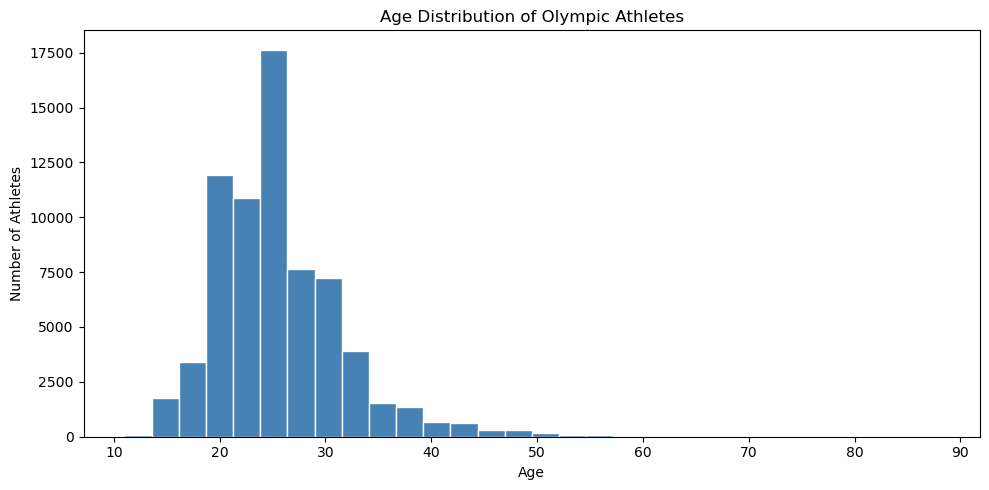

In [871]:
plt.figure(figsize=(10, 5))
plt.hist(dataset['Age'], bins=30, color='steelblue', edgecolor='white')
plt.title('Age Distribution of Olympic Athletes')
plt.xlabel('Age')
plt.ylabel('Number of Athletes')
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150)
plt.show()

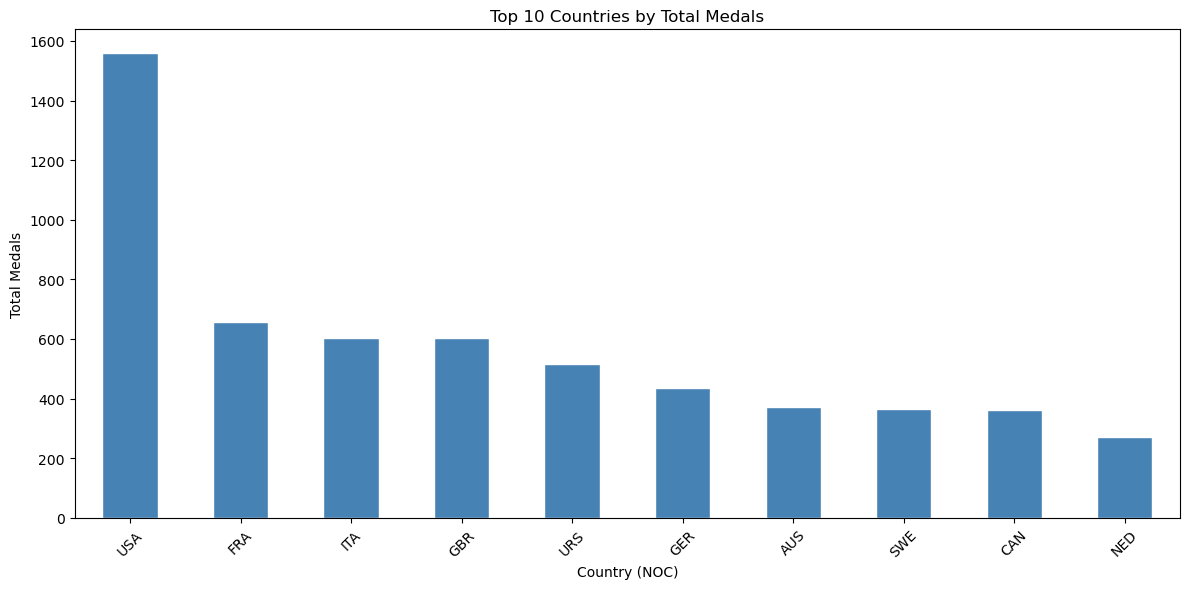

In [872]:
plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='steelblue',edgecolor='white')
plt.title('Top 10 Countries by Total Medals')
plt.xlabel('Country (NOC)')
plt.ylabel('Total Medals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_countries_medals.png', dpi=150)
plt.show()

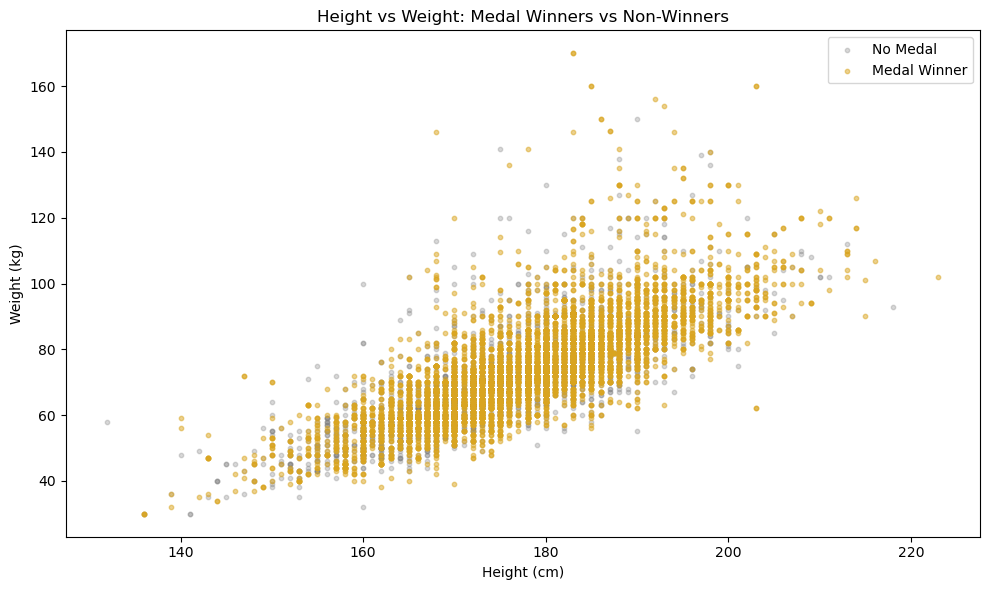

In [873]:
plt.figure(figsize=(10, 6))
medal_winners = dataset[dataset['Medal'] != 'No Medal']
no_medal = dataset[dataset['Medal'] == 'No Medal'].sample(5000)

plt.scatter(no_medal['Height'], no_medal['Weight'], 
            alpha=0.3, color='gray', label='No Medal', s=10)
plt.scatter(medal_winners['Height'], medal_winners['Weight'], 
            alpha=0.5, color='goldenrod', label='Medal Winner', s=10)
plt.title('Height vs Weight: Medal Winners vs Non-Winners')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.legend()
plt.tight_layout()
plt.savefig('height_weight_scatter.png', dpi=150)
plt.show()

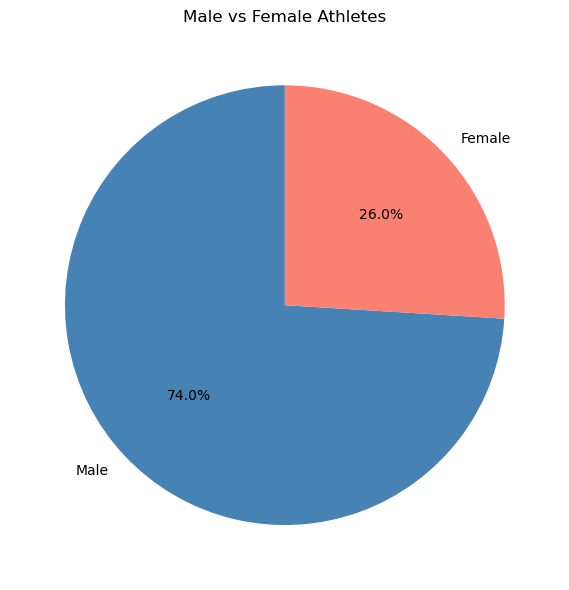

In [874]:
gender_counts = dataset['Sex'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=['Male', 'Female'], autopct='%1.1f%%', 
        colors=['steelblue', 'salmon'], startangle=90)
plt.title('Male vs Female Athletes')
plt.tight_layout()
plt.savefig('gender_split.png', dpi=150)
plt.show()

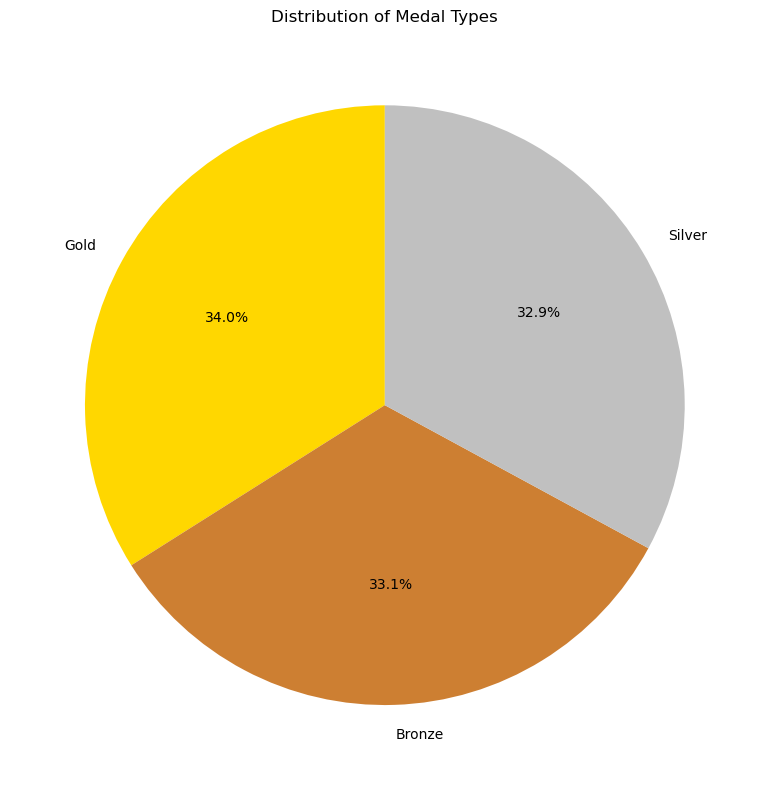

In [875]:
plt.figure(figsize=(8, 8))
medal_dist = medals_only['Medal'].value_counts()
colors = ['gold', '#cd7f32','silver', ]
plt.pie(medal_dist.values, labels=medal_dist.index, 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribution of Medal Types')
plt.tight_layout()
plt.savefig('medal_distribution_pie.png', dpi=150)
plt.show()

In [879]:
numericColumns=['Age','Height','Weight','Year']
categoryColumns=[ 'Name','Sex', 'Team', 'NOC', 'Games', 'Season','City', 'Sport','Event', 'Medal']

<Axes: >

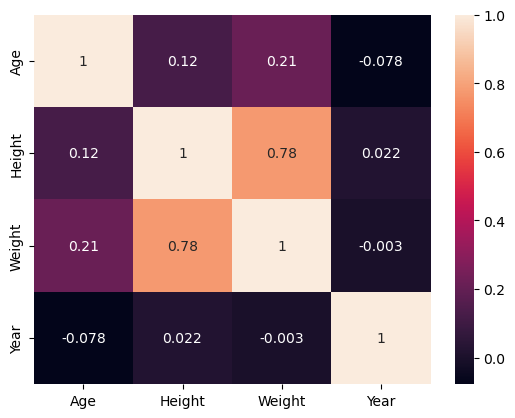

In [881]:
import seaborn as sns
sns.heatmap(dataset[numericColumns].corr(),annot=True)

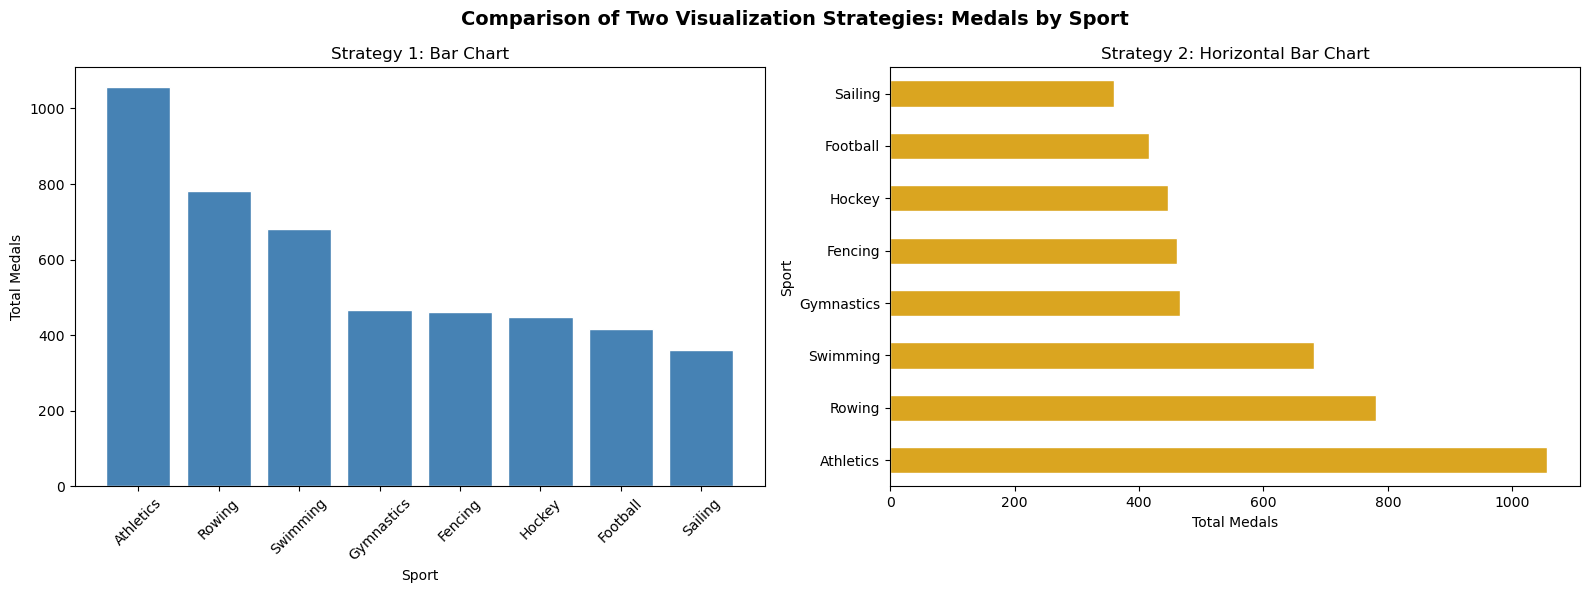

In [884]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Strategy 1 — Bar Chart
top_sports_medals = medals_only.groupby('Sport')['Medal']\
    .count().sort_values(ascending=False).head(8)
ax1.bar(top_sports_medals.index, top_sports_medals.values, 
        color='steelblue', edgecolor='white')
ax1.set_title('Strategy 1: Bar Chart')
ax1.set_xlabel('Sport')
ax1.set_ylabel('Total Medals')
ax1.tick_params(axis='x', rotation=45)

# Strategy 2 — Horizontal Bar Chart
top_sports_medals.plot(kind='barh', ax=ax2, color='goldenrod', 
                       edgecolor='white')
ax2.set_title('Strategy 2: Horizontal Bar Chart')
ax2.set_xlabel('Total Medals')
ax2.set_ylabel('Sport')

plt.suptitle('Comparison of Two Visualization Strategies: Medals by Sport', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=150)
plt.show()

In [885]:
sailingCount=(dataset['Sport']=='Sailing').sum()
sailingCount

1918

In [887]:
athleticsCount=(dataset['Sport']=='Athletics').sum()
athleticsCount

10629

In [889]:
#Hypothesis test : T-test

from scipy import stats

medal_winners_age = dataset[dataset['Medal_Winner'] == 1]['Age']
non_winners_age = dataset[dataset['Medal_Winner'] == 0]['Age']

t_stat, p_value = stats.ttest_ind(medal_winners_age, non_winners_age)

print("=== T-TEST: AGE vs MEDAL WINNING ===")
print(f"Medal Winners Mean Age: {medal_winners_age.mean():.2f}")
print(f"Non-Winners Mean Age: {non_winners_age.mean():.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: SIGNIFICANT — Age does influence medal winning")
else:
    print("Result: NOT SIGNIFICANT — Age does not significantly influence medal winning")

=== T-TEST: AGE vs MEDAL WINNING ===
Medal Winners Mean Age: 26.01
Non-Winners Mean Age: 25.40
T-Statistic: 9.1619
P-Value: 0.0000
Result: SIGNIFICANT — Age does influence medal winning


In [890]:
#Hypothesis test : Chi square test

contingency_table = pd.crosstab(dataset['Sex'], dataset['Medal_Winner'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("=== CHI-SQUARE TEST: GENDER vs MEDAL WINNING ===")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
if p_value < 0.05:
    print("Result: SIGNIFICANT — Gender is related to medal winning")
else:
    print("Result: NOT SIGNIFICANT — No significant relationship")

=== CHI-SQUARE TEST: GENDER vs MEDAL WINNING ===
Chi-Square Statistic: 4.2084
P-Value: 0.0402
Degrees of Freedom: 1
Result: SIGNIFICANT — Gender is related to medal winning


=== CORRELATION ANALYSIS ===
                Age  Height  Weight    BMI  Medal_Winner
Age           1.000   0.122   0.215  0.230         0.035
Height        0.122   1.000   0.777  0.293         0.083
Weight        0.215   0.777   1.000  0.823         0.079
BMI           0.230   0.293   0.823  1.000         0.043
Medal_Winner  0.035   0.083   0.079  0.043         1.000


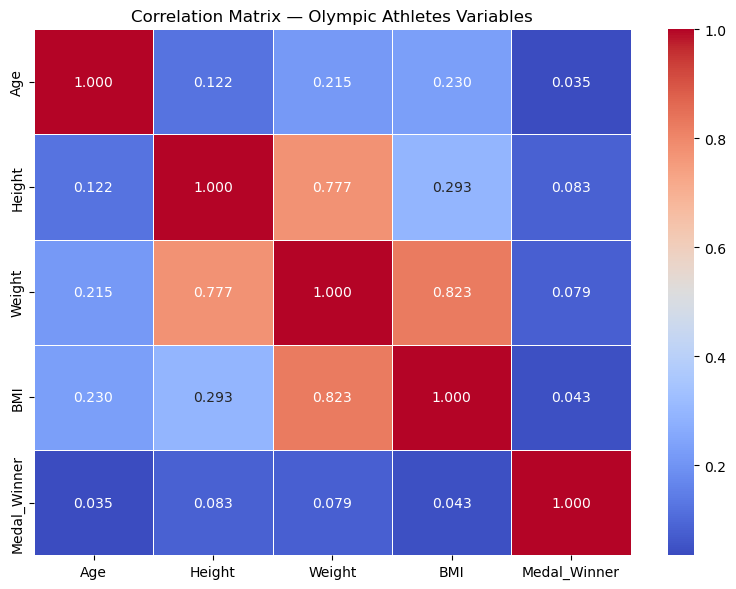

In [891]:
#Correlation analysis

print("=== CORRELATION ANALYSIS ===")
corr_cols = ['Age', 'Height', 'Weight', 'BMI', 'Medal_Winner']
correlation_matrix = dataset[corr_cols].corr()
print(correlation_matrix.round(3))

# Heatmap
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix — Olympic Athletes Variables')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

=== LINEAR REGRESSION: HEIGHT → WEIGHT ===
Coefficient: 1.0587
Intercept: -114.8077
R² Score: 0.6064
Mean Squared Error: 65.9136


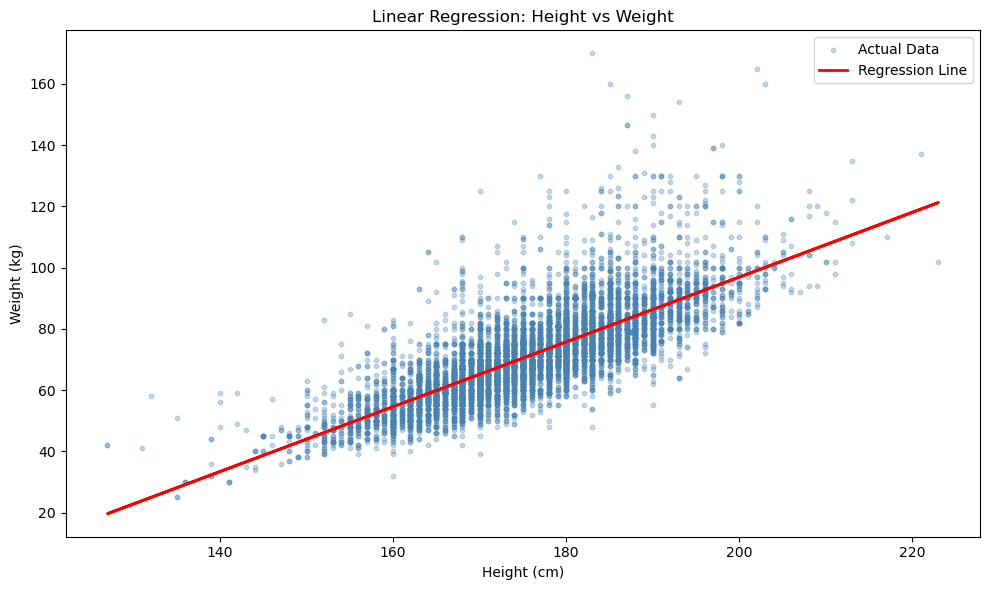

In [892]:
#Regression Analysis

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = dataset[['Height']].dropna()
y = dataset.loc[X.index, 'Weight']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== LINEAR REGRESSION: HEIGHT → WEIGHT ===")
print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

# Plot regression
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.3, color='steelblue', 
            s=10, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.legend()
plt.tight_layout()
plt.savefig('regression_plot.png', dpi=150)
plt.show()

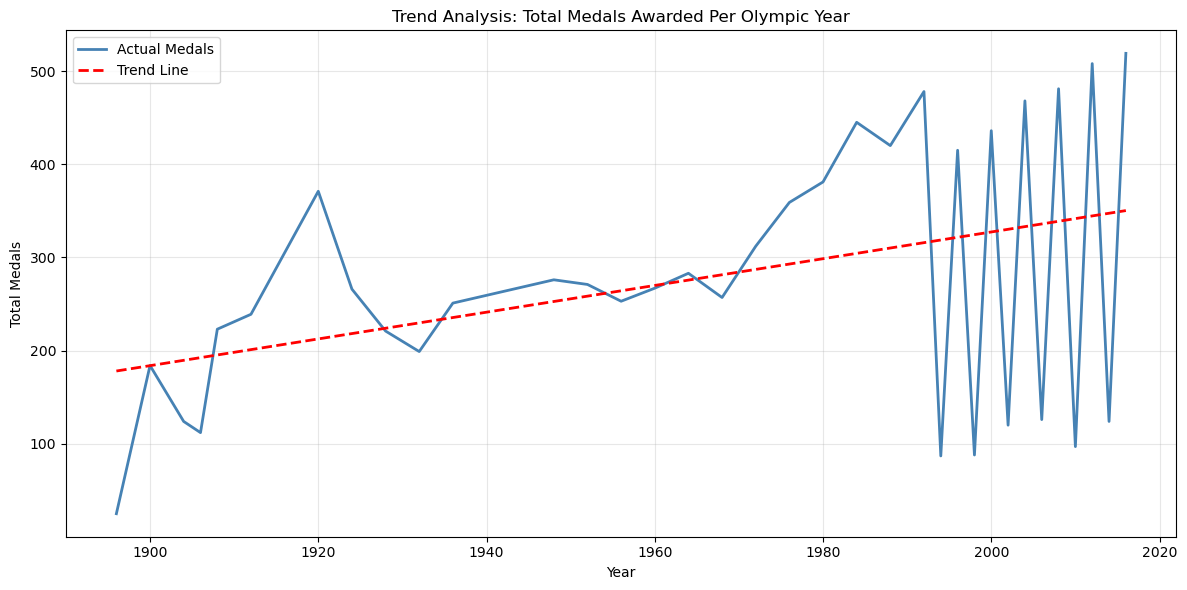

In [894]:
#Time series Analysis

plt.figure(figsize=(12, 6))
yearly_medals = medals_only.groupby('Year')['Medal'].count()
z = np.polyfit(yearly_medals.index, yearly_medals.values, 1)
p = np.poly1d(z)

plt.plot(yearly_medals.index, yearly_medals.values, 
         color='steelblue', linewidth=2, label='Actual Medals')
plt.plot(yearly_medals.index, p(yearly_medals.index), 
         color='red', linestyle='--', linewidth=2, label='Trend Line')
plt.title('Trend Analysis: Total Medals Awarded Per Olympic Year')
plt.xlabel('Year')
plt.ylabel('Total Medals')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('medal_trend.png', dpi=150)
plt.show()

In [895]:
#Uncertainity and variability analysis

print("=== VARIABILITY ANALYSIS ===")
print(f"Age Standard Deviation: {dataset['Age'].std():.2f}")
print(f"Height Standard Deviation: {dataset['Height'].std():.2f}")
print(f"Weight Standard Deviation: {dataset['Weight'].std():.2f}")
print(f"BMI Standard Deviation: {dataset['BMI'].std():.2f}")

# Confidence interval for mean age
import scipy.stats as stats
confidence = 0.95
mean_age = dataset['Age'].mean()
se = stats.sem(dataset['Age'])
ci = stats.t.interval(confidence, len(dataset['Age'])-1, 
                      loc=mean_age, scale=se)
print(f"\n95% Confidence Interval for Mean Age: ({ci[0]:.2f}, {ci[1]:.2f})")

=== VARIABILITY ANALYSIS ===
Age Standard Deviation: 6.14
Height Standard Deviation: 9.52
Weight Standard Deviation: 12.97
BMI Standard Deviation: 2.72

95% Confidence Interval for Mean Age: (25.44, 25.53)
